In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score

In [2]:
df = pd.read_excel("CTG.xls", sheet_name="Raw Data")

In [3]:
df.head()

,FileName,Date,SegFile,b,e,LBE,LB,AC,FM,UC,...,C,D,E,AD,DE,LD,FS,SUSP,CLASS,NSP
0,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Variab10.txt,1996-12-01,CTG0001.txt,240.0,357.0,120.0,120.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,9.0,2.0
2,Fmcs_1.txt,1996-05-03,CTG0002.txt,5.0,632.0,132.0,132.0,4.0,0.0,4.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,6.0,1.0
3,Fmcs_1.txt,1996-05-03,CTG0003.txt,177.0,779.0,133.0,133.0,2.0,0.0,5.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,6.0,1.0
4,Fmcs_1.txt,1996-05-03,CTG0004.txt,411.0,1192.0,134.0,134.0,2.0,0.0,6.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,6.0,1.0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2130 entries, 0 to 2129
Data columns (total 40 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   FileName  2126 non-null   object        
 1   Date      2126 non-null   datetime64[ns]
 2   SegFile   2126 non-null   object        
 3   b         2126 non-null   float64       
 4   e         2126 non-null   float64       
 5   LBE       2126 non-null   float64       
 6   LB        2126 non-null   float64       
 7   AC        2126 non-null   float64       
 8   FM        2127 non-null   float64       
 9   UC        2127 non-null   float64       
 10  ASTV      2127 non-null   float64       
 11  MSTV      2127 non-null   float64       
 12  ALTV      2127 non-null   float64       
 13  MLTV      2127 non-null   float64       
 14  DL        2128 non-null   float64       
 15  DS        2128 non-null   float64       
 16  DP        2128 non-null   float64       
 17  DR        2128

In [5]:
df.duplicated().sum()

1

In [6]:
df[df.duplicated()]

,FileName,Date,SegFile,b,e,LBE,LB,AC,FM,UC,...,C,D,E,AD,DE,LD,FS,SUSP,CLASS,NSP
2127,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
# Duplicate feature combinations
df.duplicated(subset=df.columns[:-1]).sum()

1

In [8]:
df = df.drop_duplicates()

In [9]:
df[df.duplicated(subset=df.columns[:-1], keep=False)]

,FileName,Date,SegFile,b,e,LBE,LB,AC,FM,UC,...,C,D,E,AD,DE,LD,FS,SUSP,CLASS,NSP


In [10]:
features = df.columns[:-1]

conflicting = (
    df.groupby(list(features))["NSP"]
      .nunique()
      .reset_index()
)

conflicting = conflicting[conflicting["NSP"] > 1]

df = df.merge(
    conflicting[features],
    on=list(features),
    how="left",
    indicator=True
)

df = df[df["_merge"] == "left_only"].drop(columns="_merge")

In [11]:
df.duplicated(subset=df.columns[:-1]).sum()

0

In [12]:
pd.set_option("display.max_columns", None)
df = df.dropna(how="all")
df[df.isnull().any(axis=1)]

,FileName,Date,SegFile,b,e,LBE,LB,AC,FM,UC,ASTV,MSTV,ALTV,MLTV,DL,DS,DP,DR,Width,Min,Max,Nmax,Nzeros,Mode,Mean,Median,Variance,Tendency,A,B,C,D,E,AD,DE,LD,FS,SUSP,CLASS,NSP
2127,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2128,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,564.0,23.0,87.0,7.0,91.0,50.7,16.0,1.0,4.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [13]:
df = df.drop(index=[2127, 2128])

In [14]:
df = df.drop(["FileName", "Date", "SegFile", "b", "e"], axis=1)

In [15]:
corr_with_target = df.corr()["NSP"].sort_values(ascending=False)

low_corr_features = corr_with_target[abs(corr_with_target) < 0.05]

print(low_corr_features)

Nzeros   -0.016682
Nmax     -0.023666
Max      -0.045265
Name: NSP, dtype: float64


In [16]:
df = df.drop(["Nzeros", "Nmax", "Max"], axis=1)

In [17]:
corr_matrix = df.corr()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

high_corr_pairs = []

for col in upper.columns:
    for row in upper.index:
        corr_value = upper.loc[row, col]

        if pd.notnull(corr_value) and abs(corr_value) > 0.8:
            high_corr_pairs.append((row, col, corr_value))

for pair in high_corr_pairs:
    print(pair)

('LBE', 'LB', 1.0)
('Width', 'Min', -0.8985189643113362)
('Mode', 'Mean', 0.8934123838327099)
('Mode', 'Median', 0.9333991564866512)
('Mean', 'Median', 0.9482513380408181)


In [18]:
df = df.drop(["Width", "Mode", "Median"], axis=1)

In [19]:
summary = df.agg(['min', 'max', 'mean']).T
print(summary)

            min    max        mean
LBE       106.0  160.0  133.303857
LB        106.0  160.0  133.303857
AC          0.0   26.0    2.722484
FM          0.0  564.0    7.241298
UC          0.0   23.0    3.659925
ASTV       12.0   87.0   46.990122
MSTV        0.2    7.0    1.332785
ALTV        0.0   91.0    9.846660
MLTV        0.0   50.7    8.187629
DL          0.0   16.0    1.570085
DS          0.0    1.0    0.003293
DP          0.0    4.0    0.126058
DR          0.0    0.0    0.000000
Min        50.0  159.0   93.579492
Mean       73.0  182.0  134.610536
Variance    0.0  269.0   18.808090
Tendency   -1.0    1.0    0.320320
A           0.0    1.0    0.180621
B           0.0    1.0    0.272342
C           0.0    1.0    0.024929
D           0.0    1.0    0.038100
E           0.0    1.0    0.033866
AD          0.0    1.0    0.156162
DE          0.0    1.0    0.118532
LD          0.0    1.0    0.050329
FS          0.0    1.0    0.032455
SUSP        0.0    1.0    0.092662
CLASS       1.0   10

In [20]:
df = df.drop(["DR", "Variance"], axis=1)

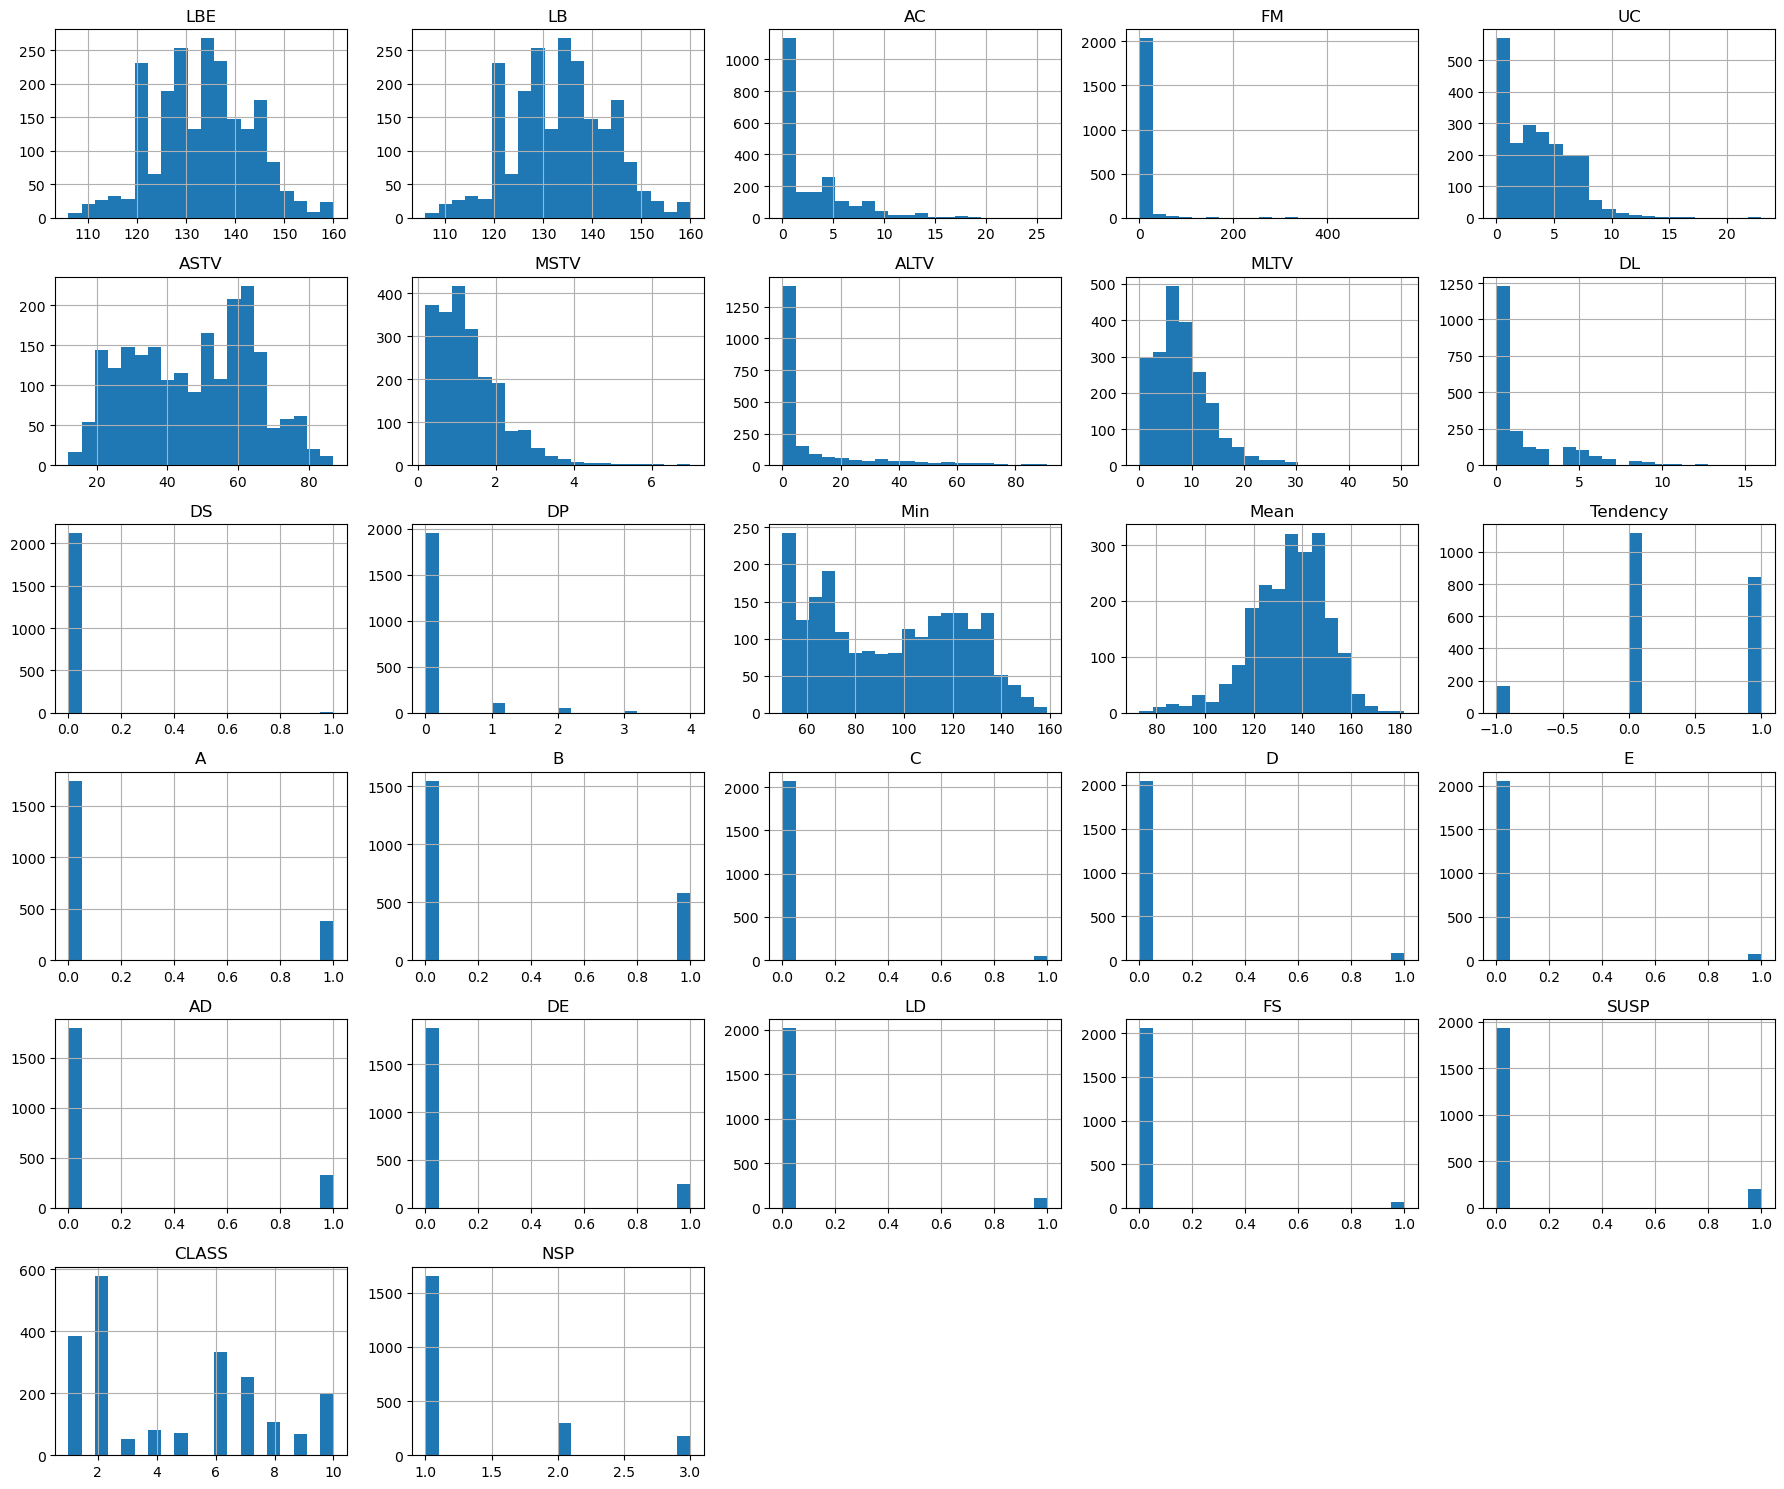

In [21]:
df.hist(figsize=(18,15), bins=20)

plt.tight_layout()
plt.show()

In [22]:
# Separate features and target
X = df.drop("NSP", axis=1)   # predictors
y = df["NSP"]                # label

In [23]:
# Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [24]:
# Create scaler
scaler = StandardScaler()

# Learn mean and standard deviation from training data
X_train_scaled = scaler.fit_transform(X_train)

# Apply same transformation to test data
X_test_scaled = scaler.transform(X_test)

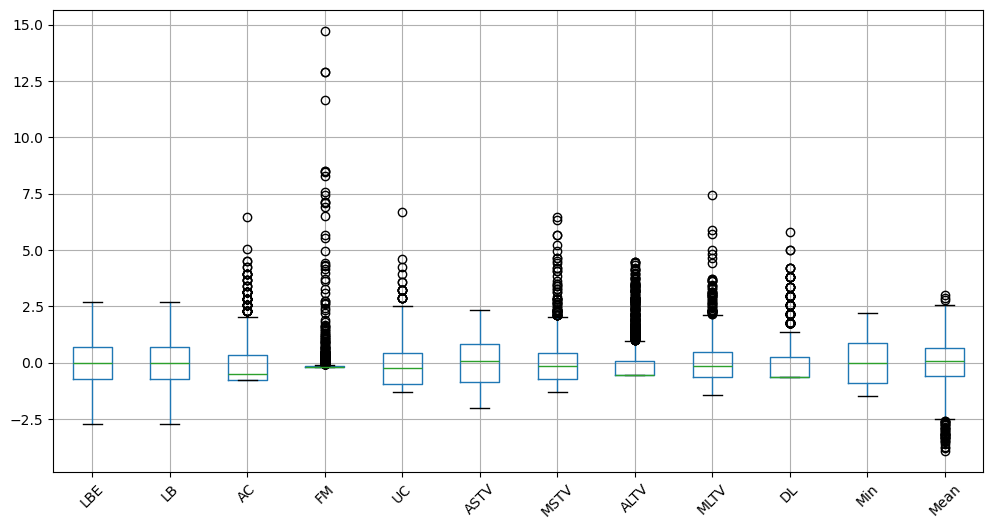

In [25]:
# Identify outliers
X_train_scaled2 = pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns,
    index=X_train.index
)

features = ["LBE", "LB", "AC", "FM", "UC", "ASTV", "MSTV","ALTV", "MLTV", "DL", "Min", "Mean"]

X_train_scaled2[features].boxplot(figsize=(12, 6), rot=45)
plt.show()

In [26]:
# Logistic regression model
log_model = LogisticRegression(random_state=42, max_iter=1000)
log_model.fit(X_train_scaled, y_train)

y_pred_log = log_model.predict(X_test_scaled)

# Decision Tree Classifier model
dt_model = DecisionTreeClassifier(
    random_state=42
)

dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

# Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=100,   # number of trees
    max_depth=10,       # max tree depth
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

# Support Vector Machine model
svm_model = SVC(
    kernel="rbf",
    random_state=42
)

svm_model.fit(X_train_scaled, y_train)

y_pred_svm = svm_model.predict(X_test_scaled)


# Neural Network model

nn_model = MLPClassifier(
    hidden_layer_sizes=(100,),
    activation="relu",
    solver="adam",
    max_iter=1000,
    random_state=42
)

nn_model.fit(X_train_scaled, y_train)

y_pred_nn = nn_model.predict(X_test_scaled)

In [27]:
# Evaluate

from sklearn.metrics import accuracy_score, classification_report

models = {
    "Logistic Regression": (log_model, y_pred_log),
    "Decision Tree": (dt_model, y_pred_dt),
    "Random Forest": (rf_model, y_pred_rf),
    "Support Vector Machine": (svm_model, y_pred_svm),
    "Neural Network": (nn_model, y_pred_nn)
}

for name, (model, predictions) in models.items():
    print(f"\n{name}")
    print(f"Accuracy: {accuracy_score(y_test, predictions):.4f}")
    print(classification_report(y_test, predictions))


Logistic Regression
Accuracy: 0.9789
              precision    recall  f1-score   support

         1.0       0.99      0.98      0.99       333
         2.0       0.91      0.95      0.93        64
         3.0       1.00      0.97      0.98        29

    accuracy                           0.98       426
   macro avg       0.97      0.97      0.97       426
weighted avg       0.98      0.98      0.98       426


Decision Tree
Accuracy: 0.9789
              precision    recall  f1-score   support

         1.0       0.99      0.99      0.99       333
         2.0       0.94      0.92      0.93        64
         3.0       1.00      0.97      0.98        29

    accuracy                           0.98       426
   macro avg       0.97      0.96      0.97       426
weighted avg       0.98      0.98      0.98       426


Random Forest
Accuracy: 0.9812
              precision    recall  f1-score   support

         1.0       0.99      0.99      0.99       333
         2.0       0.94    

In [28]:

print(f"{'Model':<25} {'Accuracy':>10} {'Macro F1':>10}")
print("-" * 47)

for name, (model, predictions) in models.items():
    accuracy = accuracy_score(y_test, predictions)
    macro_f1 = f1_score(y_test, predictions, average='macro')

    print(f"{name:<25} {accuracy:.4f} {macro_f1:.4f}")

Model                       Accuracy   Macro F1
-----------------------------------------------
Logistic Regression       0.9789 0.9672
Decision Tree             0.9789 0.9665
Random Forest             0.9812 0.9698
Support Vector Machine    0.9859 0.9760
Neural Network            0.9836 0.9731


In [29]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_scaled, y_train)

baseline_accuracy = rf.score(X_test_scaled, y_test)
print(f"Baseline Accuracy: {baseline_accuracy:.4f}")

Baseline Accuracy: 0.9836


In [30]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2']
}

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train_scaled, y_train)

print("Best Parameters:")
print(grid_search.best_params_)

print("Best Cross Validation Accuracy:")
print(grid_search.best_score_)

Best Parameters:
{'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}
Best Cross Validation Accuracy:
0.99


In [31]:
best_rf = grid_search.best_estimator_

y_pred = best_rf.predict(X_test_scaled)

from sklearn.metrics import accuracy_score, classification_report

print("Test Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Test Accuracy: 0.9812206572769953
              precision    recall  f1-score   support

         1.0       0.99      0.99      0.99       333
         2.0       0.94      0.94      0.94        64
         3.0       1.00      0.97      0.98        29

    accuracy                           0.98       426
   macro avg       0.98      0.96      0.97       426
weighted avg       0.98      0.98      0.98       426



In [32]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[330   3   0]
 [  4  60   0]
 [  0   1  28]]


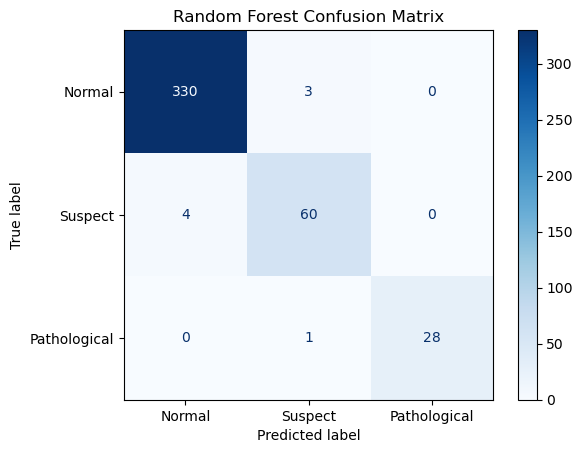

In [33]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Normal", "Suspect", "Pathological"]
)

disp.plot(cmap="Blues")
plt.title("Random Forest Confusion Matrix")
plt.show()

In [34]:
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import label_binarize

y_prob = best_rf.predict_proba(X_test_scaled)

macro_auc = roc_auc_score(
    y_test,
    y_prob,
    multi_class='ovr',   # One-vs-Rest
    average='macro'
)

print("Macro ROC AUC:", macro_auc)



Macro ROC AUC: 0.9903576205694309


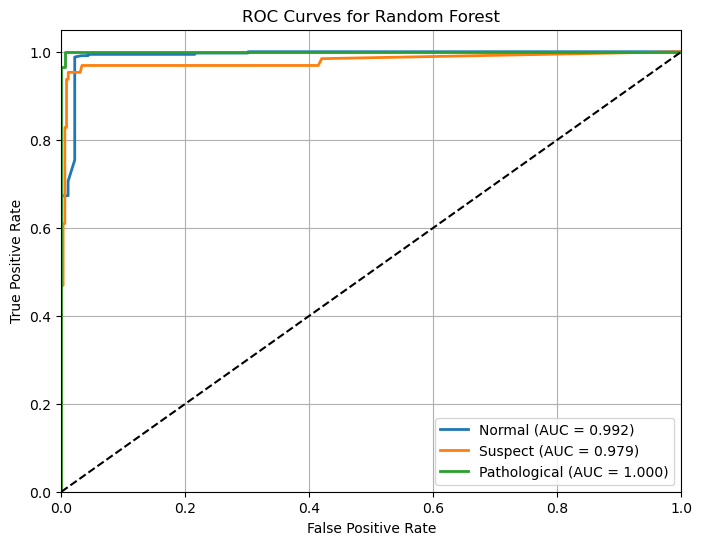

In [35]:
# Convert labels to binary
y_test_bin = label_binarize(y_test, classes=[1, 2, 3])

plt.figure(figsize=(8,6))

class_names = ['Normal', 'Suspect', 'Pathological']

for i in range(3):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, lw=2,
             label=f'{class_names[i]} (AUC = {roc_auc:.3f})')

plt.plot([0,1], [0,1], 'k--')
plt.xlim([0,1])
plt.ylim([0,1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for Random Forest")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()